In [3]:
import numpy as np
import pandas as pd
df = pd.read_excel("dhaka_apartments.xlsx")

In [ ]:
df.head()

,apartment_id,location,size_sqft,bedrooms,bathrooms,age_years,furnished,rent
0,1,Uttara,1893,4,3,15,Yes,43000
1,2,Mohammadpur,713,2,1,25,No,13000
2,3,Dhanmondi,1290,2,1,13,Yes,37000
3,4,Mirpur,1370,3,2,2,No,30500
4,5,Banani,1695,3,2,9,No,49000


In [4]:
df.shape

(33, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   apartment_id  33 non-null     int64 
 1   location      33 non-null     object
 2   size_sqft     33 non-null     int64 
 3   bedrooms      33 non-null     int64 
 4   bathrooms     33 non-null     int64 
 5   age_years     33 non-null     int64 
 6   furnished     33 non-null     object
 7   rent          33 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 2.2+ KB


In [6]:
df.describe()

,apartment_id,size_sqft,bedrooms,bathrooms,age_years,rent
count,33.00000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.00000,1547.181818,3.030303,2.515152,10.878788,41515.151515
std,9.66954,670.945110,0.883348,1.121417,7.012300,30503.453915
min,1.00000,655.000000,2.000000,1.000000,0.000000,12500.000000
25%,9.00000,1231.000000,2.000000,2.000000,6.000000,30000.000000
50%,17.00000,1517.000000,3.000000,2.000000,11.000000,37000.000000
75%,25.00000,1965.000000,4.000000,3.000000,15.000000,48000.000000
max,33.00000,4200.000000,5.000000,5.000000,25.000000,195000.000000


In [ ]:
df.isnull().sum()

,0
apartment_id,0
location,0
size_sqft,0
bedrooms,0
bathrooms,0
age_years,0
furnished,0
rent,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **Measures of Central Tenency**

**Ques: Find the mean rent and the mean size_sqft.**

In [ ]:
print(df["rent"].mean())

41515.15151515151


In [ ]:
print(df["size_sqft"].mean())

1547.1818181818182


**Ques: Find the Median rent?**

In [ ]:
print(df["rent"].median())

37000.0


**Ques:Compare the mean and median of rent. Are they close or far apart? Is the data balanced or skewed?**

In [ ]:
print(df["rent"].mean())
print(df["rent"].median())

41515.15151515151
37000.0


Mean is well above median -> rent is right-skewed (a few costly flats).

**Ques: Find the mode (most common) location. (Hint: mode() or value_counts())**

In [ ]:
print(df["location"].mode())

print(df["location"].value_counts())

0    Mirpur
Name: location, dtype: object
location
Mirpur         6
Mohammadpur    5
Uttara         5
Dhanmondi      5
Banani         4
Gulshan        4
Bashundhara    4
Name: count, dtype: int64


**Ques:Show how many flats are in each location, and the percentage in each.**

In [ ]:
print(df["location"].value_counts())

location
Mirpur         6
Mohammadpur    5
Uttara         5
Dhanmondi      5
Banani         4
Gulshan        4
Bashundhara    4
Name: count, dtype: int64


In [ ]:
print((df["location"].value_counts(normalize=True) * 100).round(1))

location
Mirpur         18.2
Mohammadpur    15.2
Uttara         15.2
Dhanmondi      15.2
Banani         12.1
Gulshan        12.1
Bashundhara    12.1
Name: proportion, dtype: float64


# **Measures of Dispersion**

**1. Range:**

Range = largest value − smallest value. It is the simplest measure of spread.

**Ques: Find the range of rent?**

In [ ]:
df["rent"].max() -df["rent"].min()

182500

It is fast, but it only looks at two values (the top and bottom), so one outlier can fool it.

**2. Variance**

Variance = the average of the squared distances from the mean.

In [ ]:
print(df["rent"].var())

930460700.7575756


**3. Standard Deviation**

**Standard deviation = the square root of the variance.** It is the *typical distance* of a value from the mean, in the original units.

In [ ]:
print(df["rent"].std())

30503.453915213857


**Ques. Find the correlation between size_sqft and rent. Is it positive or negative? Strong or weak?**

In [7]:
print(df["size_sqft"].corr(df["rent"]))

0.9069535321550265


here the correlation between size_sqft and rent is **strong positive**

**Ques. Print the correlation matrix for size_sqft, bedrooms, age_years, rent. Which pair is the most strongly related?**

In [8]:
print(df[["size_sqft", "bedrooms", "age_years", "rent"]].corr().round(2))

           size_sqft  bedrooms  age_years  rent
size_sqft       1.00      0.89      -0.32  0.91
bedrooms        0.89      1.00      -0.28  0.67
age_years      -0.32     -0.28       1.00 -0.31
rent            0.91      0.67      -0.31  1.00


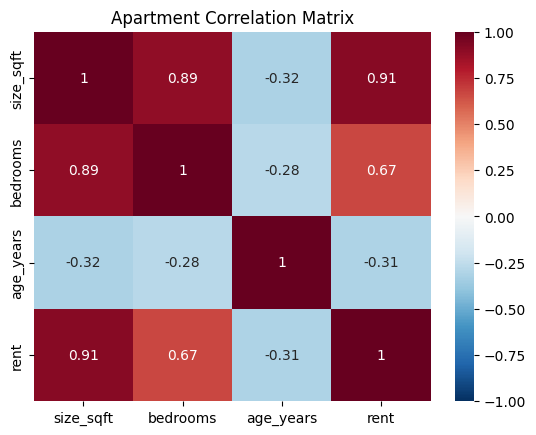

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = (df[["size_sqft", "bedrooms", "age_years", "rent"]].corr().round(2))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin = -1, vmax = 1)
plt.title("Apartment Correlation Matrix")
plt.show()

# **Key Summary:**

The Correlation heatmap showes that-


*   Rent is strongly influenced by apartment size(0.91) and moderately influenced by the number of bedrooms(0.67)
*   Apartment age has weak negative correlation with rent(-0.31), indicating that older aparments tend to have slightly lower rents.

Overall, larger apartments with more bedrooms are generally more expensive to rent.

But Correlation is not causation. Bathrooms and rent rise together because
bigger flats have both -> size is the real driver, not the bathroom.
